In [3]:
import pandas as pd

fp32 = pd.read_csv("outputs/day03_fp32_results.csv")
int8 = pd.read_csv("int8_results.csv")



print("FP32 detections:", len(fp32))
print("INt8 detections:", len(int8))

print("\nFP32 confidence mean:", fp32["confidence"].mean())
print("FP32 confidence standard deviation:", fp32["confidence"].std())

print("\nINT8 confidence mean:", int8["confidence"].mean())
print("INT8 confidence standard deviation:", int8["confidence"].std())


FP32 detections: 367
INt8 detections: 2121

FP32 confidence mean: 0.31830115060065683
FP32 confidence standard deviation: 0.08607033653634978

INT8 confidence mean: 0.699853446561174
INT8 confidence standard deviation: 0.11683766734312113


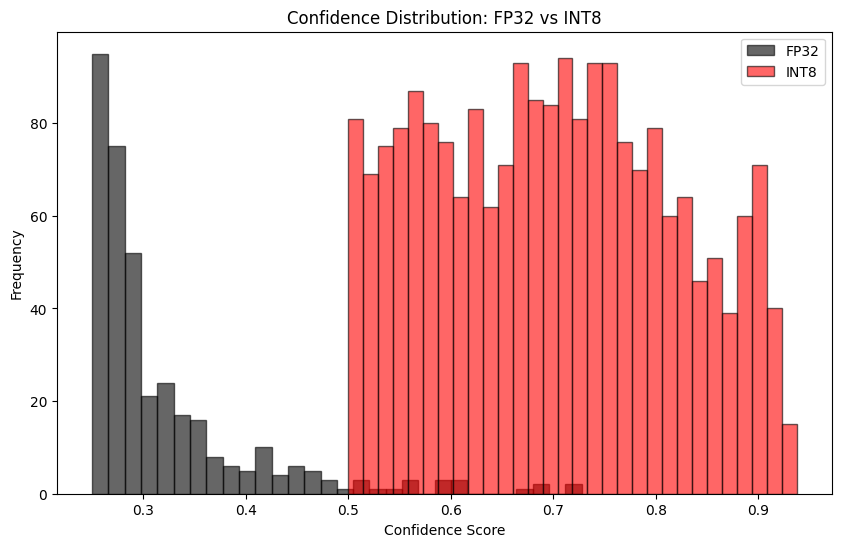

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(fp32["confidence"], bins=30, alpha=0.6, label="FP32", color="black", edgecolor="black")
plt.hist(int8["confidence"], bins=30, alpha=0.6, label="INT8", color="red", edgecolor="black")

plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("Confidence Distribution: FP32 vs INT8")
plt.legend()
plt.savefig("confidence_distribution.png", dpi=300)
plt.show()

In [6]:
fp32_frame_counts = fp32.groupby("frame").size()
int8_frame_counts = int8.groupby("frame").size()

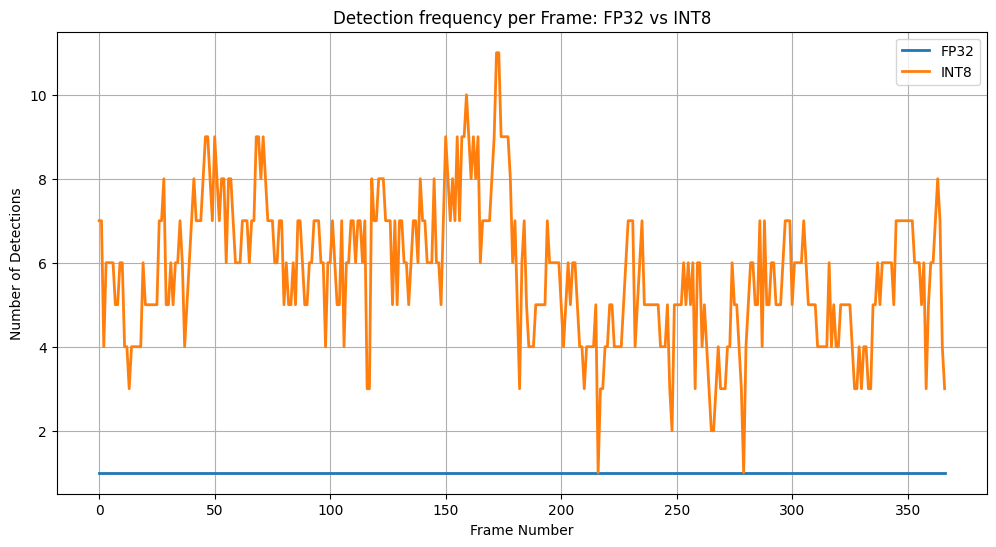

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(fp32_frame_counts.index,
         fp32_frame_counts.values,
         label="FP32",
         linewidth=2)

plt.plot(int8_frame_counts.index,
         int8_frame_counts.values,
         label="INT8",
         linewidth=2)

plt.xlabel("Frame Number")
plt.ylabel("Number of Detections")
plt.title("Detection frequency per Frame: FP32 vs INT8")

plt.legend()
plt.grid(True)
plt.savefig("detections_per_frame.jpg", dpi=300)
plt.show()

In [9]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(fp32["confidence"], int8["confidence"])

print("Mann-Whitney U Statistic:",stat)
print("p-value:", p_value)

Mann-Whitney U Statistic: 9829.0
p-value: 7.168534677832424e-196


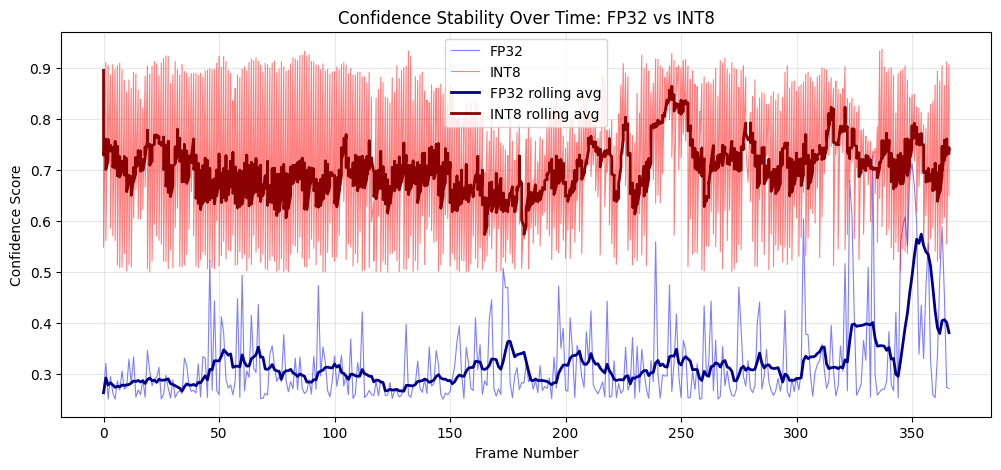

In [21]:
# Temporal stability — confidence value over time
plt.figure(figsize=(12, 5))
plt.plot(fp32["frame"], fp32["confidence"], 
         color="blue", alpha=0.5, linewidth=0.8, label="FP32")
plt.plot(int8["frame"], int8["confidence"], 
         color="red", alpha=0.5, linewidth=0.8, label="INT8")

# Rolling average to show the smooth trend
fp32_rolling = fp32["confidence"].rolling(window=10, min_periods=1).mean()
int8_rolling = int8["confidence"].rolling(window=10, min_periods=1).mean()
plt.plot(fp32["frame"], fp32_rolling, color="darkblue", linewidth=2, label="FP32 rolling avg")
plt.plot(int8["frame"], int8_rolling, color="darkred", linewidth=2, label="INT8 rolling avg")

plt.xlabel("Frame Number")
plt.ylabel("Confidence Score")
plt.title("Confidence Stability Over Time: FP32 vs INT8")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("confidence_temporal.jpg", dpi=300)  # save BEFORE show
plt.show()